# Trial-to-paid conversion diagnostic

## tl;dr

This reproducible diagnostic separates the observed mature-cohort conversion decline from acquisition mix, activation, payment failures, plan mix, and cohort-maturity effects. It is descriptive and does not claim that any product change caused the decline.


## Context & Methods

### Key Assumptions

- The designed decline begins on April 19, 2026 (day 108 of the 180-day seeded scenario).
- Only mature trial cohorts are included.
- A conversion is a paid start occurring between trial start and the configured number of days after scheduled trial end.
- The standardized comparison holds the pre-decline acquisition-channel mix fixed.
- Confidence intervals use a normal approximation to the binomial proportion and are descriptive.


In [1]:
from datetime import datetime, timezone
from pathlib import Path
import subprocess

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

working_path = Path.cwd().resolve()
repo_root = next(
    path for path in [working_path, *working_path.parents]
    if (path / "game_analytics").is_dir() and (path / "pyproject.toml").exists()
)
db_path = repo_root / "game_analytics" / "dev.duckdb"
__import__("os").chdir(repo_root / "game_analytics")

source_models = [
    "mart_subscription__trial_conversion_diagnostic",
    "mart_subscription__kpis_daily",
    "fct_subscription__payments",
    "int_subscription__quality_audit",
    "int_subscription__trial_cohorts",
    "dim_subscription__users",
]
execution_date = datetime.now(timezone.utc).isoformat()
filters = {
    "mature_trials_only": True,
    "conversion_window_days": 3,
    "decline_start_date": "2026-04-19",
}
code_version = subprocess.check_output(
    ["git", "-C", str(repo_root), "rev-parse", "HEAD"], text=True
).strip()

connection = duckdb.connect(str(db_path), read_only=True)
print({
    "source_models": source_models,
    "execution_date": execution_date,
    "filters": filters,
    "code_version": code_version,
})


{'source_models': ['mart_subscription__trial_conversion_diagnostic', 'mart_subscription__kpis_daily', 'fct_subscription__payments', 'int_subscription__quality_audit', 'int_subscription__trial_cohorts', 'dim_subscription__users'], 'execution_date': '2026-09-10T02:23:39.572148+00:00', 'filters': {'mature_trials_only': True, 'conversion_window_days': 3, 'decline_start_date': '2026-04-19'}, 'code_version': '4d954927a1280c700254cd167b9f5f1e9c20de7d'}


## Data

Load governed aggregate outputs, the scenario quality audit, and bounded trial-level fields required for conversion-window sensitivity.


In [2]:
diagnostic = connection.sql("""
    select *
    from main_subscription.mart_subscription__trial_conversion_diagnostic
    order by cohort_date, acquisition_channel, campaign_id, plan_id, activation_segment
""").df()

kpis = connection.sql("""
    select metric_date, trial_to_paid_numerator, trial_to_paid_denominator,
           trial_to_paid_rate, data_quality_status
    from main_subscription.mart_subscription__kpis_daily
    where trial_to_paid_denominator is not null
    order by metric_date
""").df()

quality = connection.sql("select * from main_subscription.int_subscription__quality_audit").df()

trial_detail = connection.sql("""
    select
        t.subscription_id,
        t.cohort_date,
        t.trial_start_at,
        t.scheduled_trial_end_at,
        t.paid_start_at,
        t.plan_id,
        t.maturity_cutoff_date,
        u.acquisition_channel,
        u.campaign_id,
        case
            when u.activation_at >= u.signup_at
             and u.activation_at <= t.scheduled_trial_end_at
            then 'activated_before_trial_end'
            else 'not_activated_before_trial_end'
        end as activation_segment,
        exists (
            select 1 from main_subscription.fct_subscription__payments p
            where p.subscription_id = t.subscription_id
              and p.is_failed
              and p.payment_at >= t.trial_start_at
              and p.payment_at <= t.scheduled_trial_end_at + interval '3 days'
        ) as has_payment_failure
    from main_subscription.int_subscription__trial_cohorts t
    join main_subscription.dim_subscription__users u using (user_id)
    where t.is_mature
    order by t.cohort_date, t.subscription_id
""").df()

maturity_cutoff_date = pd.to_datetime(trial_detail["maturity_cutoff_date"]).max().date()
decline_start_date = pd.Timestamp(filters["decline_start_date"])
trial_detail["period"] = np.where(
    pd.to_datetime(trial_detail["cohort_date"]) < decline_start_date,
    "Pre-decline",
    "Post-decline",
)
trial_detail["converted_3d"] = (
    trial_detail["paid_start_at"].notna()
    & (trial_detail["paid_start_at"] >= trial_detail["trial_start_at"])
    & (
        trial_detail["paid_start_at"]
        <= trial_detail["scheduled_trial_end_at"] + pd.Timedelta(days=3)
    )
)

print(f"Mature trials: {len(trial_detail):,}")
print(f"Latest maturity cutoff date: {maturity_cutoff_date}")
display(quality)


Mature trials: 180
Latest maturity cutoff date: 2026-07-21


/var/folders/1b/b3w1gmp5697_6n57wv0kc9yr0000gn/T/ipykernel_2035/2422035320.py:59: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  <= trial_detail["scheduled_trial_end_at"] + pd.Timedelta(days=3)


,duplicate_webhook_rows,late_cancellation_rows,missing_campaign_users,unmapped_activation_events,local_time_trial_end_rows
0,5,6,60,320,124


## Results

### 1. Mature-cohort conversion and uncertainty


,period,paid_conversions,eligible_trials,rate,ci_low,ci_high
0,Pre-decline,33,104,31.73%,22.79%,40.68%
1,Post-decline,21,76,27.63%,17.58%,37.69%


Observed decline: 4.10 percentage points


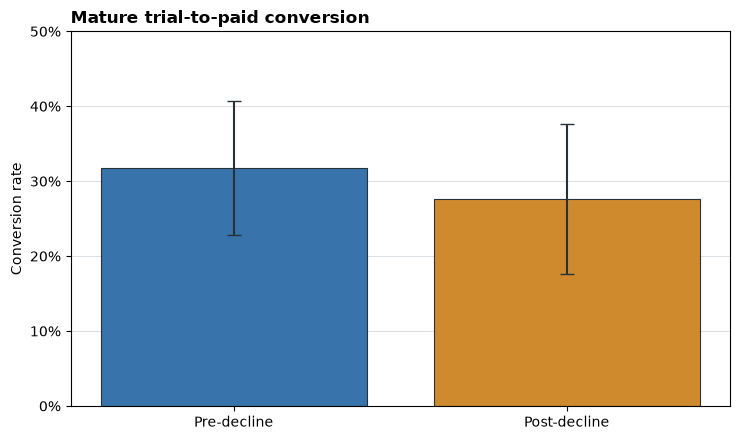

In [3]:
def summarize_rate(frame: pd.DataFrame, converted_col: str = "converted_3d") -> pd.DataFrame:
    result = (
        frame.groupby("period", observed=True)[converted_col]
        .agg(["sum", "count"])
        .rename(columns={"sum": "paid_conversions", "count": "eligible_trials"})
        .reset_index()
    )
    result["rate"] = result["paid_conversions"] / result["eligible_trials"]
    se = np.sqrt(result["rate"] * (1 - result["rate"]) / result["eligible_trials"])
    result["ci_low"] = (result["rate"] - 1.96 * se).clip(lower=0)
    result["ci_high"] = (result["rate"] + 1.96 * se).clip(upper=1)
    return result

period_order = ["Pre-decline", "Post-decline"]
overall = summarize_rate(trial_detail).set_index("period").loc[period_order].reset_index()
pre_rate, post_rate = overall["rate"].tolist()
decline_pp = (pre_rate - post_rate) * 100
display(overall.style.format({"rate": "{:.2%}", "ci_low": "{:.2%}", "ci_high": "{:.2%}"}))
print(f"Observed decline: {decline_pp:.2f} percentage points")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
palette = ["#3973AC", "#D08A2E"]
errors = np.vstack([overall["rate"] - overall["ci_low"], overall["ci_high"] - overall["rate"]])
ax.bar(overall["period"], overall["rate"], color=palette, edgecolor="#263238", linewidth=0.8)
ax.errorbar(overall["period"], overall["rate"], yerr=errors, fmt="none", ecolor="#263238", capsize=5)
ax.set_title("Mature trial-to-paid conversion", loc="left", weight="bold")
ax.set_ylabel("Conversion rate")
ax.set_ylim(0, max(0.5, float(overall["ci_high"].max()) + 0.05))
ax.yaxis.set_major_formatter(lambda value, _position: f"{value:.0%}")
ax.grid(axis="y", color="#D9DEE3", linewidth=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


### 2. Channel-mix standardization and segment diagnostics


In [4]:
channel = (
    trial_detail.groupby(["period", "acquisition_channel"], observed=True)["converted_3d"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "paid_conversions", "count": "eligible_trials"})
    .reset_index()
)
channel["rate"] = channel["paid_conversions"] / channel["eligible_trials"]

pre_channel = channel[channel["period"] == "Pre-decline"].set_index("acquisition_channel")
post_channel = channel[channel["period"] == "Post-decline"].set_index("acquisition_channel")
pre_weights = pre_channel["eligible_trials"] / pre_channel["eligible_trials"].sum()
standardized_post_rate = float(
    (pre_weights * post_channel["rate"].reindex(pre_weights.index)).sum()
)
mix_effect_pp = (post_rate - standardized_post_rate) * 100
within_channel_effect_pp = (standardized_post_rate - pre_rate) * 100

standardization = pd.DataFrame({
    "comparison": ["Observed pre", "Observed post", "Post at pre channel mix"],
    "rate": [pre_rate, post_rate, standardized_post_rate],
})
display(standardization.style.format({"rate": "{:.2%}"}))
print(f"Channel-mix contribution to post rate: {mix_effect_pp:+.2f} pp")
print(f"Within-channel / residual contribution: {within_channel_effect_pp:+.2f} pp")

def segment_view(column: str) -> pd.DataFrame:
    output = (
        trial_detail.groupby([column, "period"], dropna=False, observed=True)["converted_3d"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "paid_conversions", "count": "eligible_trials"})
        .reset_index()
    )
    output["trial_to_paid_rate"] = output["paid_conversions"] / output["eligible_trials"]
    return output.sort_values([column, "period"])

for dimension in ["acquisition_channel", "campaign_id", "activation_segment", "has_payment_failure", "plan_id"]:
    print(f"Diagnostic by {dimension}")
    display(segment_view(dimension).style.format({"trial_to_paid_rate": "{:.2%}"}))


,comparison,rate
0,Observed pre,31.73%
1,Observed post,27.63%
2,Post at pre channel mix,27.76%


Channel-mix contribution to post rate: -0.13 pp
Within-channel / residual contribution: -3.97 pp
Diagnostic by acquisition_channel


,acquisition_channel,period,paid_conversions,eligible_trials,trial_to_paid_rate
0,organic,Post-decline,7,25,28.00%
1,organic,Pre-decline,8,26,30.77%
2,paid_search,Post-decline,6,23,26.09%
3,paid_search,Pre-decline,9,28,32.14%
4,paid_social,Post-decline,6,21,28.57%
5,paid_social,Pre-decline,14,38,36.84%
6,partner,Post-decline,2,7,28.57%
7,partner,Pre-decline,2,12,16.67%


Diagnostic by campaign_id


,campaign_id,period,paid_conversions,eligible_trials,trial_to_paid_rate
0,campaign_organic,Post-decline,7,23,30.43%
1,campaign_organic,Pre-decline,7,24,29.17%
2,campaign_partner_01,Post-decline,2,7,28.57%
3,campaign_partner_01,Pre-decline,2,10,20.00%
4,campaign_search_01,Post-decline,6,22,27.27%
5,campaign_search_01,Pre-decline,9,27,33.33%
6,campaign_social_01,Post-decline,6,21,28.57%
7,campaign_social_01,Pre-decline,13,35,37.14%
8,unknown,Post-decline,0,3,0.00%
9,unknown,Pre-decline,2,8,25.00%


...

,activation_segment,period,paid_conversions,eligible_trials,trial_to_paid_rate
0,activated_before_trial_end,Post-decline,9,36,25.00%
1,activated_before_trial_end,Pre-decline,15,50,30.00%
2,not_activated_before_trial_end,Post-decline,12,40,30.00%
3,not_activated_before_trial_end,Pre-decline,18,54,33.33%


Diagnostic by has_payment_failure


,has_payment_failure,period,paid_conversions,eligible_trials,trial_to_paid_rate
0,False,Post-decline,21,74,28.38%
1,False,Pre-decline,33,99,33.33%
2,True,Post-decline,0,2,0.00%
3,True,Pre-decline,0,5,0.00%


Diagnostic by plan_id


,plan_id,period,paid_conversions,eligible_trials,trial_to_paid_rate
0,annual_premium,Post-decline,11,38,28.95%
1,annual_premium,Pre-decline,12,56,21.43%
2,monthly_basic,Post-decline,10,38,26.32%
3,monthly_basic,Pre-decline,21,48,43.75%


### 3. Conversion-window sensitivity and data-quality qualification


In [5]:
sensitivity_rows = []
for window_days in [2, 3, 7]:
    converted = (
        trial_detail["paid_start_at"].notna()
        & (trial_detail["paid_start_at"] >= trial_detail["trial_start_at"])
        & (
            trial_detail["paid_start_at"]
            <= trial_detail["scheduled_trial_end_at"] + pd.Timedelta(days=window_days)
        )
    )
    working = trial_detail.assign(converted_window=converted)
    result = summarize_rate(working, "converted_window").set_index("period")
    sensitivity_rows.append({
        "conversion_window_days": window_days,
        "pre_rate": result.loc["Pre-decline", "rate"],
        "post_rate": result.loc["Post-decline", "rate"],
        "decline_pp": (
            result.loc["Pre-decline", "rate"] - result.loc["Post-decline", "rate"]
        ) * 100,
    })

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.style.format({"pre_rate": "{:.2%}", "post_rate": "{:.2%}", "decline_pp": "{:.2f}"}))

quality_counts = quality.iloc[0].to_dict()
print("Quality-audit counts:", quality_counts)
print("Payment failure incidence by period:")
display(
    trial_detail.groupby("period", observed=True)["has_payment_failure"]
    .agg(["sum", "count"])
    .assign(rate=lambda frame: frame["sum"] / frame["count"])
    .style.format({"rate": "{:.2%}"})
)


/var/folders/1b/b3w1gmp5697_6n57wv0kc9yr0000gn/T/ipykernel_2035/3534248559.py:8: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  <= trial_detail["scheduled_trial_end_at"] + pd.Timedelta(days=window_days)
/var/folders/1b/b3w1gmp5697_6n57wv0kc9yr0000gn/T/ipykernel_2035/3534248559.py:8: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  <= trial_detail["scheduled_trial_end_at"] + pd.Timedelta(days=window_days)
/var/folders/1b/b3w1gmp5697_6n57wv0kc9yr0000gn/T/ipykernel_2035/3534248559.py:8: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`

,conversion_window_days,pre_rate,post_rate,decline_pp
0,2,31.73%,27.63%,4.10
1,3,31.73%,27.63%,4.10
2,7,31.73%,27.63%,4.10


Quality-audit counts: {'duplicate_webhook_rows': 5, 'late_cancellation_rows': 6, 'missing_campaign_users': 60, 'unmapped_activation_events': 320, 'local_time_trial_end_rows': 124}
Payment failure incidence by period:


,sum,count,rate
period,,,
Post-decline,2,76,2.63%
Pre-decline,5,104,4.81%


## Takeaways

- The notebook quantifies the mature-cohort decline and its binomial uncertainty directly from governed dbt outputs.
- Holding the pre-decline channel mix fixed isolates the small composition component from the larger within-channel/residual component.
- Payment failures, activation status, plan, campaign, and conversion-window sensitivity are shown as diagnostics, not causal estimates.
- The five intentional data-quality conditions remain visible beside the findings. The corresponding incident record defines their containment.
- This is synthetic observational evidence. It supports a reversible experiment and measurement repair, not a causal claim.
